# ResNet34 - Transfer Learning Model

## 1. Setup

In [ ]:
!pip install numpy matplotlib seaborn scikit-learn --quiet
!pip install torch torchvision torchaudio --quiet
!pip install torchmetrics --quiet
!pip install grad-cam --quiet
!pip install tabulate --quiet

In [11]:
import time, copy, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
%matplotlib inline
from torchvision import models, transforms, datasets
from torchmetrics import Accuracy, Precision, Recall, F1Score
from sklearn.metrics import classification_report, confusion_matrix

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

## 2. Reproducibility + Device

In [12]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", DEVICE)

Using: cpu


## 3. Paths

In [ ]:
# Detecting if running on Google Colab
try:
    from google.colab import drive
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

if ON_COLAB:
    drive.mount('/content/drive')

    OUTPUT_DIR       = Path('/content/drive/MyDrive/COMP472/outputs/resnet34_tl')
    preprocessed_dir = Path('/content/drive/MyDrive/brain_mri_preprocessed')

# If not on Colab, use your own local paths 
else:
    OUTPUT_DIR       = Path('/outputs_resnet34_tl')
    preprocessed_dir = Path('../brain_mri_preprocessed')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Running on Colab: {ON_COLAB}")
print(f"Output directory : {OUTPUT_DIR}")
print(f"Preprocessed dir : {preprocessed_dir}")
print(f"Exists?          : {preprocessed_dir.exists()}")


Running on Colab: False
Output directory : C:\Users\kalin\Desktop\outputs_resnet34_tl
Preprocessed dir : C:\Users\kalin\Desktop\brain_mri_preprocessed
Exists?          : True


## 4. Hyperparameters

In [14]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 44

# Phase 1
LR_P1 = 1e-3
EPOCHS_P1 = 10

# Phase 2
LR_P2 = 1e-5
EPOCHS_P2 = 10

WEIGHT_DECAY = 1e-4

## 5 Transforms & DataLoaders

MRI images are grayscale while ResNet expects RGB

In [15]:
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3,1,1)),   # grayscale → RGB
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3,1,1)),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

### Load Dataset

In [16]:
# Load preprocessed dataset
data = torch.load(preprocessed_dir / "dataset3_preprocessed.pt")

images = data["images"]   # shape [N, 3, H, W]
labels = data["labels"]   # shape [N]
class_names = [f"class_{i}" for i in range(44 )]

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Unique classes:", labels.unique())

Images: torch.Size([4478, 1, 224, 224])
Labels: torch.Size([4478])
Unique classes: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43])


In [17]:
from torch.utils.data import Dataset

class PreprocessedDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]

        # If grayscale, convert to 3 channels
        if img.shape[0] == 1:
            img = img.repeat(3, 1, 1)

        return img, self.labels[idx]

In [18]:
from torch.utils.data import random_split
full_ds = PreprocessedDataset(images, labels)
print("Total samples:", len(full_ds))

train_size = int(0.7 * len(full_ds))
val_size   = int(0.15 * len(full_ds))
test_size  = len(full_ds) - train_size - val_size

train_ds, val_ds, test_ds = random_split(full_ds, [train_size, val_size, test_size])

Total samples: 4478


In [19]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

## 6. ResNet34 Model Construction

In [20]:
def build_model():
    model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, NUM_CLASSES)
    return model.to(DEVICE)

## 7. Freezing & Unfreezing

In [21]:
# Phase 1: Freezing all conv layers
def freeze_backbone(model):
    for name, param in model.named_parameters():
        if not name.startswith("fc"):
            param.requires_grad = False

In [22]:
# Phase 2: Unfreezing the last block (layer4) and the fully connected layer (fc)
def unfreeze_last_block(model):
    for name, param in model.named_parameters():
        if name.startswith("layer4") or name.startswith("fc"):
            param.requires_grad = True

## 8. Training & Evaluation Functions

In [23]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum = 0
    acc = Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(DEVICE)

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * imgs.size(0)
        acc.update(out.argmax(1), labels)

    return loss_sum / len(loader.dataset), acc.compute().item()


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum = 0
    acc = Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(DEVICE)

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = model(imgs)
        loss_sum += criterion(out, labels).item() * imgs.size(0)
        acc.update(out.argmax(1), labels)

    return loss_sum / len(loader.dataset), acc.compute().item()

## 9. Evaluation

In [24]:
@torch.no_grad()
def full_evaluation(model, loader):
    model.eval()
    preds_all, labels_all = [], []

    metrics = {
        "acc":  Accuracy(task="multiclass", num_classes=NUM_CLASSES, average="macro").to(DEVICE),
        "prec": Precision(task="multiclass", num_classes=NUM_CLASSES, average="macro").to(DEVICE),
        "rec":  Recall(task="multiclass", num_classes=NUM_CLASSES, average="macro").to(DEVICE),
        "f1":   F1Score(task="multiclass", num_classes=NUM_CLASSES, average="macro").to(DEVICE),
    }

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs).argmax(1)

        for m in metrics.values():
            m.update(preds, labels)

        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    results = {k: v.compute().item() for k,v in metrics.items()}
    print(classification_report(labels_all, preds_all, target_names=class_names))
    return results, preds_all, labels_all

## 10. Phase Runner

In [25]:
def run_phase(model, epochs, lr, label, save_path):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val = float("inf")
    best_w = None

    print(f"\n{label} — Trainable params:",
            sum(p.numel() for p in model.parameters() if p.requires_grad))

    for ep in range(1, epochs+1):
        t0 = time.time()
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer)
        vl, va = evaluate(model, test_loader, criterion)
        scheduler.step(vl)

        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)

        flag = ""
        if vl < best_val:
            best_val = vl
            best_w = copy.deepcopy(model.state_dict())
            torch.save(best_w, save_path)
            flag = "  ✓"

        print(f"Ep {ep:02d} | Train {tl:.4f}/{ta:.4f} | Val {vl:.4f}/{va:.4f} | {time.time()-t0:.1f}s{flag}")

    model.load_state_dict(best_w)
    return model, history

In [26]:
print("DATA_DIR:", preprocessed_dir)
print("Exists:", preprocessed_dir.exists())
print("Contents:", list(preprocessed_dir.iterdir()))

DATA_DIR: C:\Users\kalin\Desktop\brain_mri_preprocessed
Exists: True
Contents: [WindowsPath('C:/Users/kalin/Desktop/brain_mri_preprocessed/dataset1_preprocessed.pt'), WindowsPath('C:/Users/kalin/Desktop/brain_mri_preprocessed/dataset1_test_preprocessed.pt'), WindowsPath('C:/Users/kalin/Desktop/brain_mri_preprocessed/dataset2_preprocessed.pt'), WindowsPath('C:/Users/kalin/Desktop/brain_mri_preprocessed/dataset3_preprocessed.pt'), WindowsPath('C:/Users/kalin/Desktop/brain_mri_preprocessed/normalization_stats.pt'), WindowsPath('C:/Users/kalin/Desktop/brain_mri_preprocessed/verification.png')]


## 11. Feature Extraction

In [27]:
model = build_model()
freeze_backbone(model)

ckpt_p1 = OUTPUT_DIR / "resnet34_phase1.pth"

model, hist_p1 = run_phase(
    model, EPOCHS_P1, LR_P1,
    "Phase 1 — Feature Extraction", ckpt_p1
)

results_p1, preds_p1, labels_p1 = full_evaluation(model, test_loader)


Phase 1 — Feature Extraction — Trainable params: 22572
Ep 01 | Train 2.8619/0.2754 | Val 2.1705/0.4562 | 60.7s  ✓
Ep 02 | Train 1.8646/0.5262 | Val 1.6688/0.5527 | 61.2s  ✓
Ep 03 | Train 1.4878/0.6184 | Val 1.4857/0.5884 | 63.3s  ✓
Ep 04 | Train 1.2450/0.6835 | Val 1.3331/0.6211 | 63.2s  ✓
Ep 05 | Train 1.0937/0.7208 | Val 1.2442/0.6300 | 64.4s  ✓
Ep 06 | Train 0.9830/0.7451 | Val 1.1676/0.6553 | 63.5s  ✓
Ep 07 | Train 0.8914/0.7709 | Val 1.1162/0.6924 | 61.7s  ✓
Ep 08 | Train 0.8232/0.7945 | Val 1.1020/0.6909 | 63.8s  ✓
Ep 09 | Train 0.7507/0.8101 | Val 1.0279/0.7177 | 63.5s  ✓
Ep 10 | Train 0.6998/0.8338 | Val 1.0065/0.7073 | 61.9s  ✓
              precision    recall  f1-score   support

     class_0       0.67      0.75      0.71        24
     class_1       0.79      0.69      0.74        39
     class_2       0.36      0.40      0.38        25
     class_3       1.00      1.00      1.00         8
     class_4       0.93      0.87      0.90        15
     class_5       0.71      

## 12. Fine-Tuning

In [28]:
from torchvision import models
import torch.nn as nn

def build_model():
    model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, NUM_CLASSES)
    return model.to(DEVICE)

model = build_model()
model.load_state_dict(torch.load(ckpt_p1))
unfreeze_last_block(model)

ckpt_p2 = OUTPUT_DIR / "resnet34_phase2.pth"

model, hist_p2 = run_phase(
    model, EPOCHS_P2, LR_P2,
    "Phase 2 — Fine-Tuning", ckpt_p2
)

results_p2, preds_p2, labels_p2 = full_evaluation(model, test_loader)


Phase 2 — Fine-Tuning — Trainable params: 21307244
Ep 01 | Train 0.5519/0.8689 | Val 0.7379/0.8039 | 158.7s  ✓
Ep 02 | Train 0.2564/0.9700 | Val 0.6268/0.8113 | 149.5s  ✓
Ep 03 | Train 0.1394/0.9917 | Val 0.5421/0.8484 | 167.1s  ✓
Ep 04 | Train 0.0887/0.9968 | Val 0.5047/0.8544 | 168.8s  ✓
Ep 05 | Train 0.0617/0.9974 | Val 0.4781/0.8544 | 168.4s  ✓
Ep 06 | Train 0.0457/0.9978 | Val 0.4540/0.8603 | 169.0s  ✓
Ep 07 | Train 0.0334/0.9984 | Val 0.4400/0.8678 | 171.9s  ✓
Ep 08 | Train 0.0264/0.9978 | Val 0.4315/0.8692 | 169.9s  ✓
Ep 09 | Train 0.0247/0.9984 | Val 0.4139/0.8707 | 171.0s  ✓
Ep 10 | Train 0.0180/0.9990 | Val 0.4055/0.8767 | 170.4s  ✓
              precision    recall  f1-score   support

     class_0       0.91      0.83      0.87        24
     class_1       0.94      0.87      0.91        39
     class_2       0.84      0.84      0.84        25
     class_3       0.80      1.00      0.89         8
     class_4       0.93      0.87      0.90        15
     class_5       0.71

## 13. Visualization Functions

### Training Curves

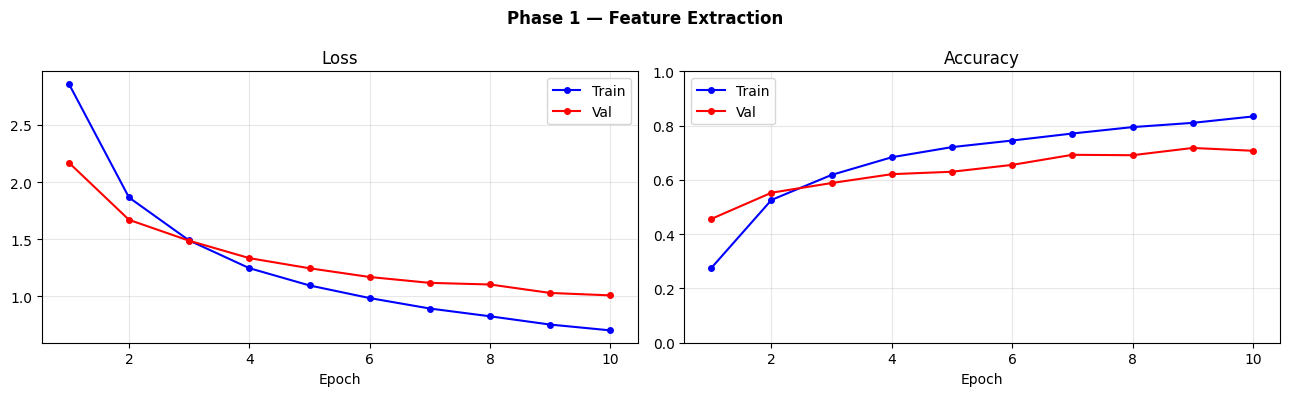

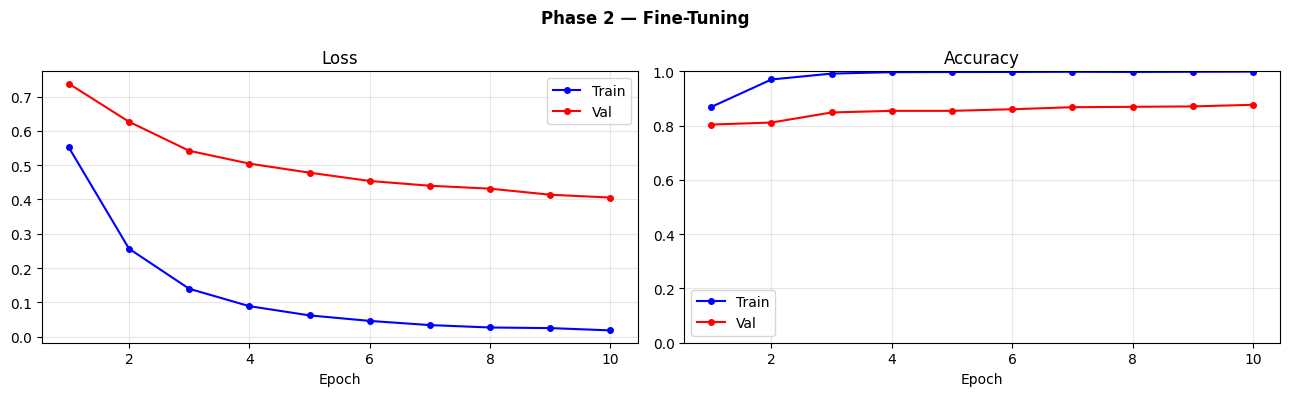

In [29]:
def plot_curves(history, title, save_path):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontweight='bold')

    for ax, key, label in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
        ax.plot(epochs, history[f'train_{key}'], 'b-o', ms=4, label='Train')
        ax.plot(epochs, history[f'val_{key}'],   'r-o', ms=4, label='Val')
        ax.set_title(label)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(alpha=0.3)
        if key == 'acc':
            ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(block=True)

plot_curves(hist_p1, "Phase 1 — Feature Extraction", OUTPUT_DIR / "resnet34_phase1_curves.png")
plot_curves(hist_p2, "Phase 2 — Fine-Tuning", OUTPUT_DIR / "resnet34_phase2_curves.png")


### Confusion Matrix

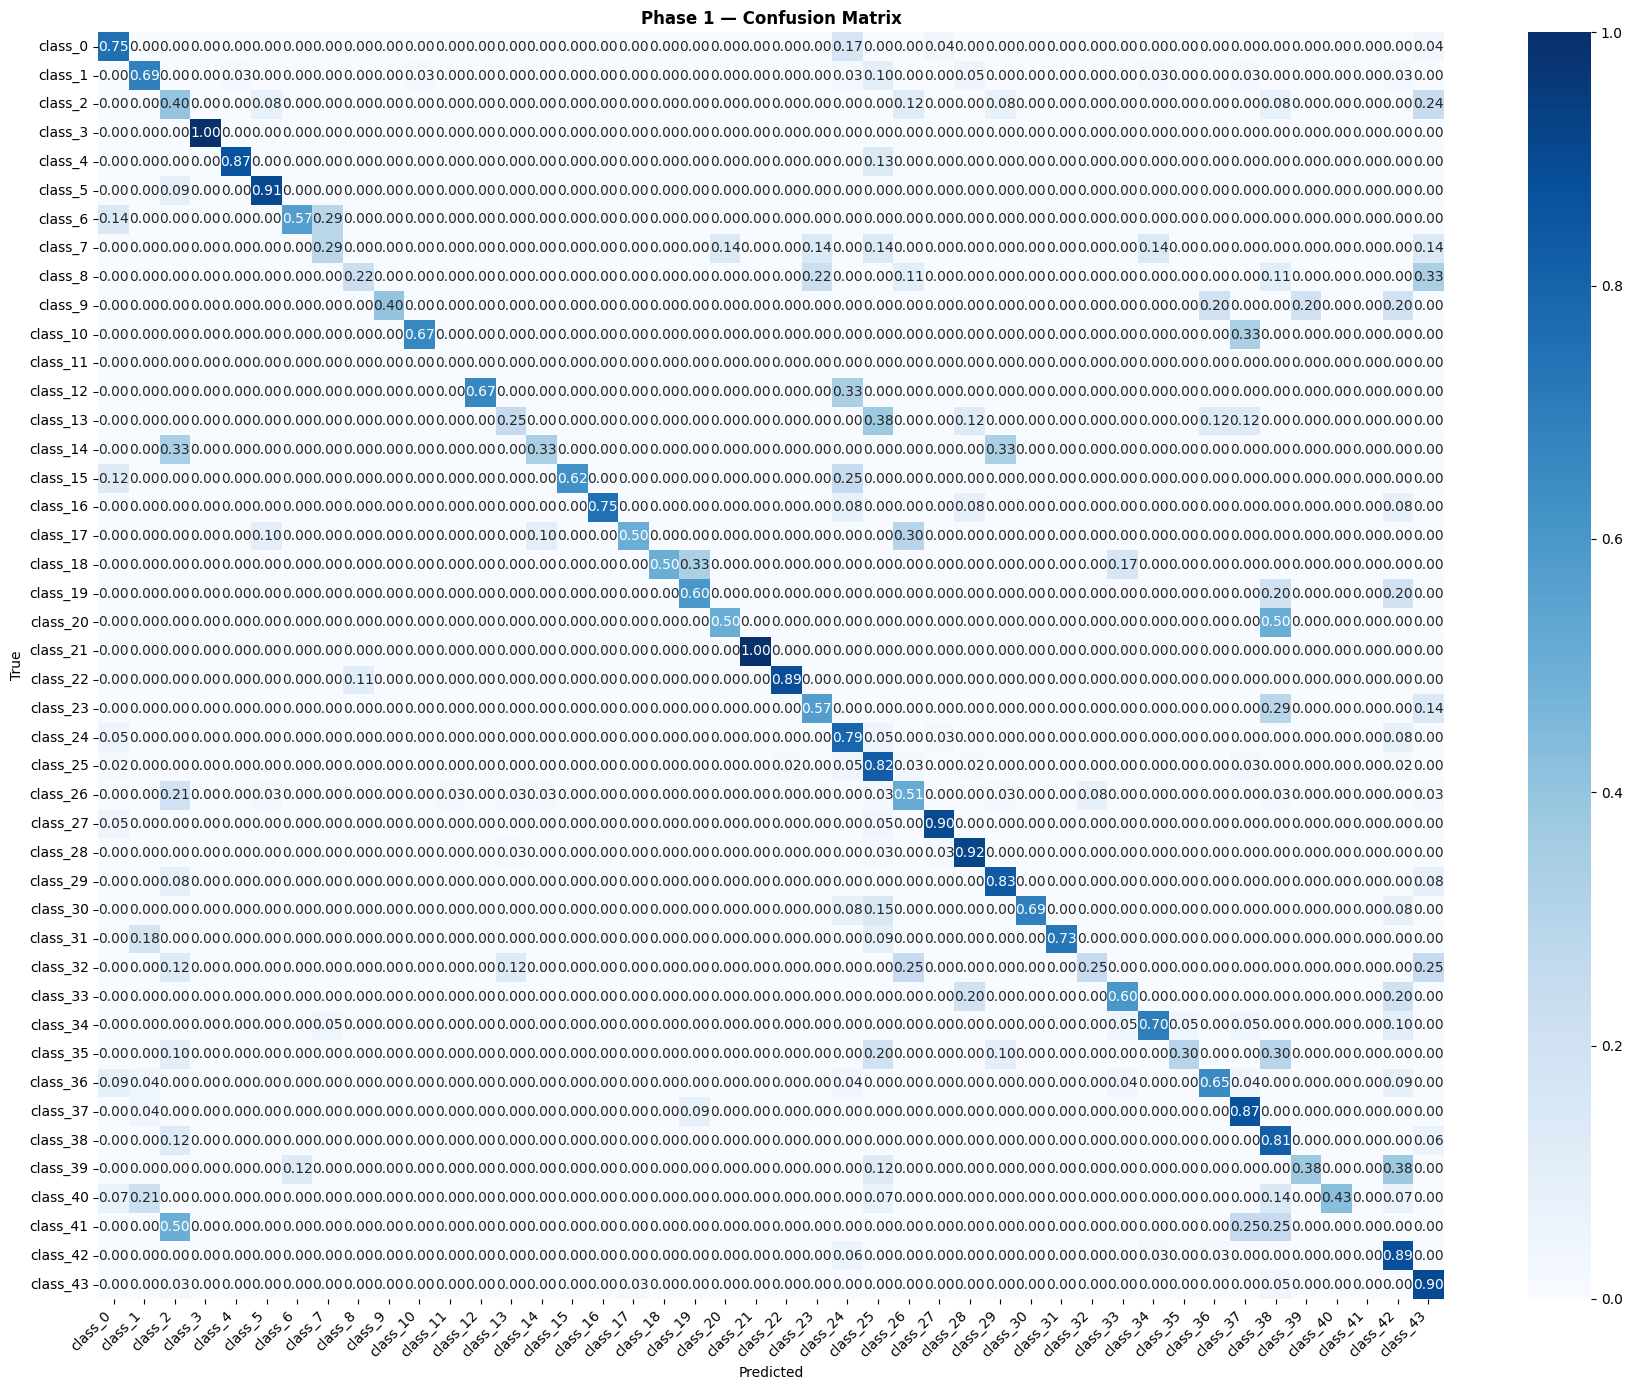

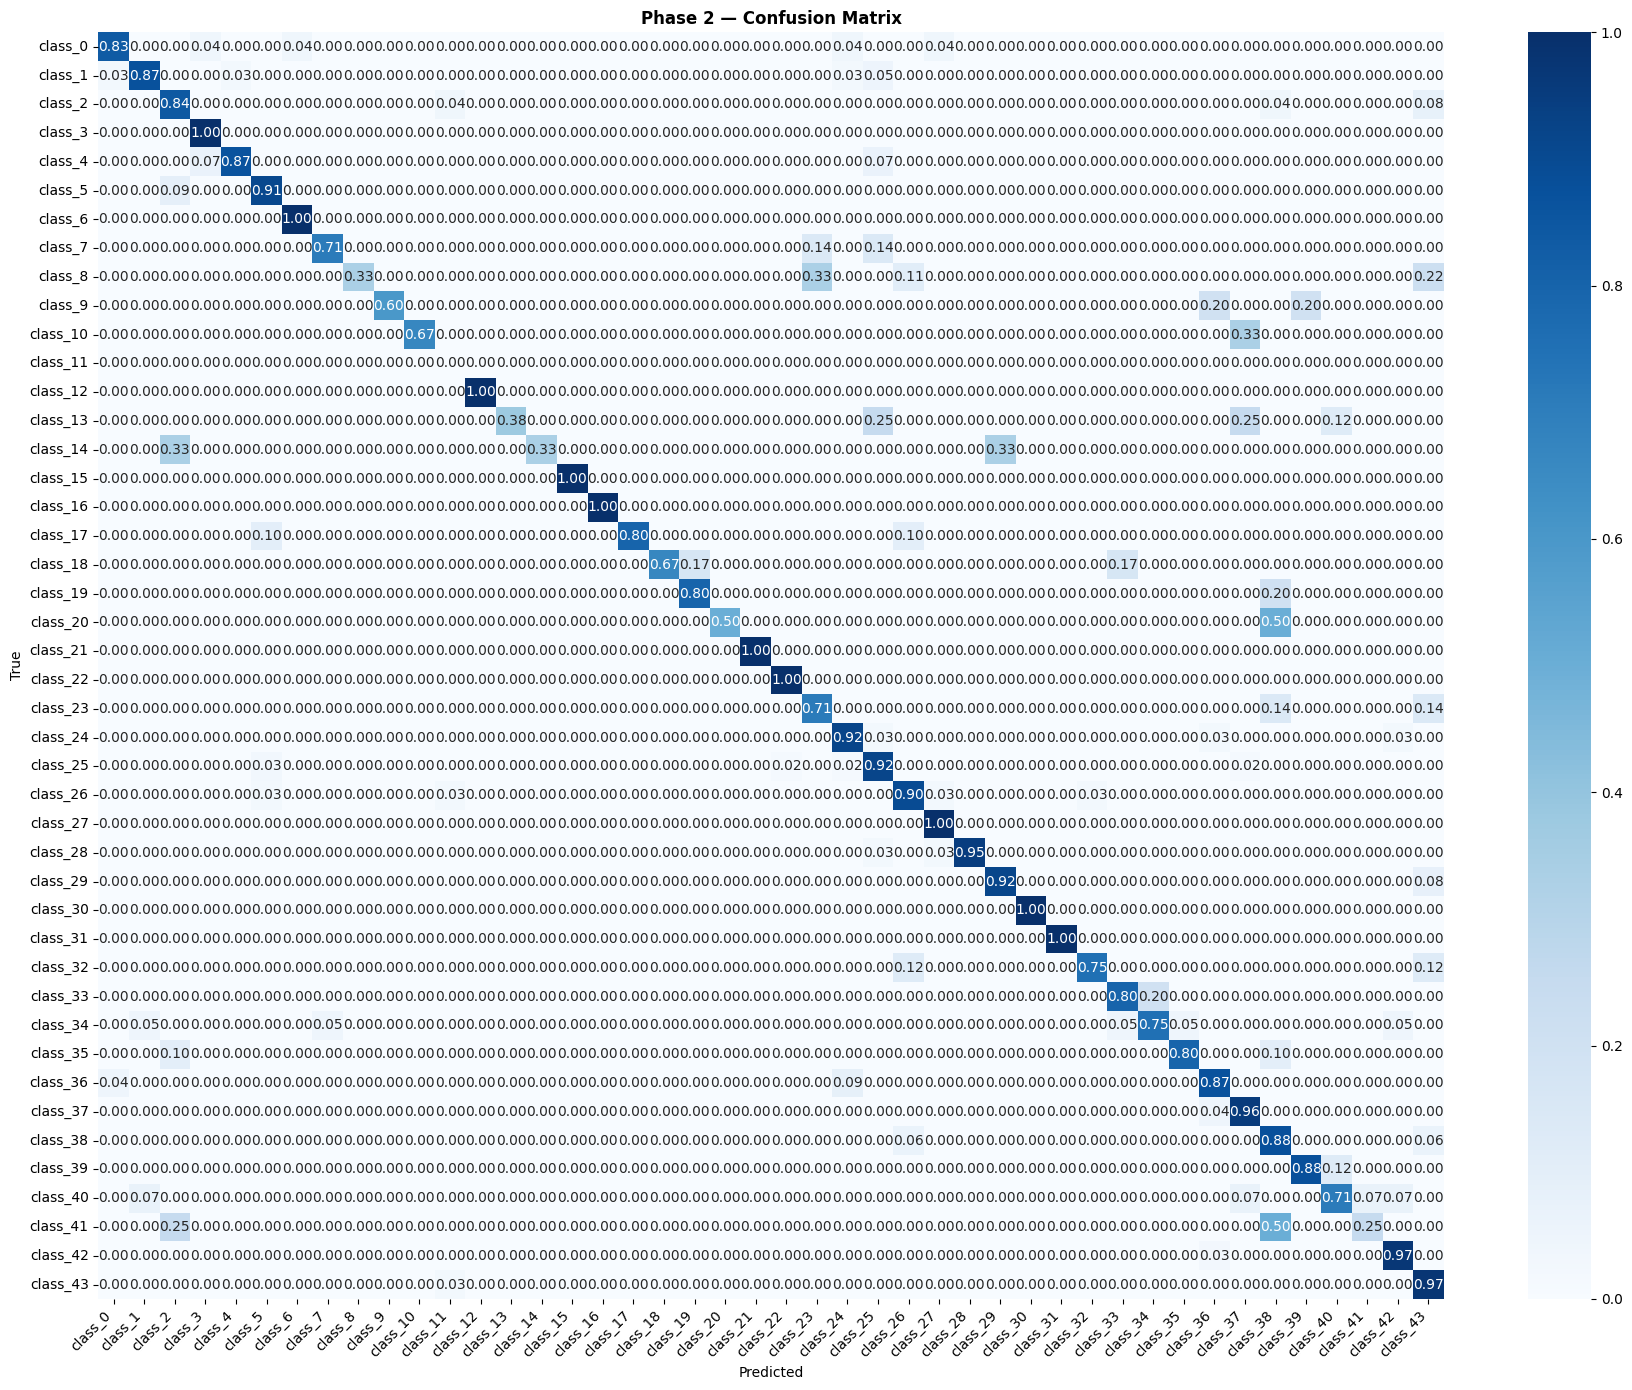

In [30]:
def plot_confusion_matrix(labels, preds, class_names, title, save_path):
    cm = confusion_matrix(labels, preds, normalize='true')

    fig, ax = plt.subplots(figsize=(18, 14))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(labels_p1, preds_p1, class_names,
                        "Phase 1 — Confusion Matrix", OUTPUT_DIR / "resnet34_phase1_cm.png")
plot_confusion_matrix(labels_p2, preds_p2, class_names,
                        "Phase 2 — Confusion Matrix", OUTPUT_DIR / "resnet34_phase2_cm.png")

### Grad-CAM Visualization

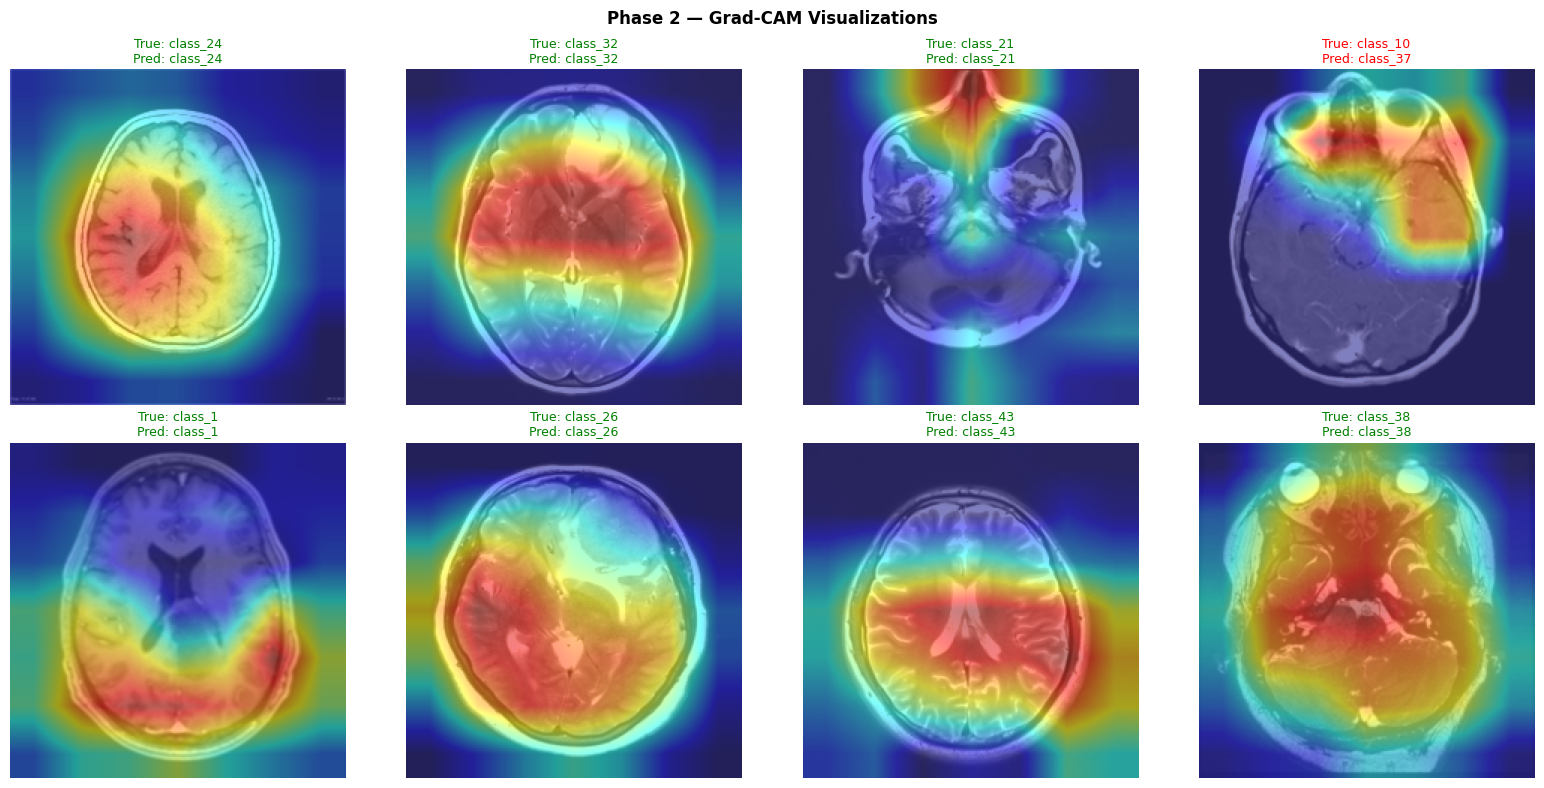

In [31]:
def plot_grad_cam(model, loader, class_names, title, save_path, n=8):
    model.eval()

    target_layer = model.layer4[-1]
    cam = GradCAM(model=model, target_layers=[target_layer])

    imgs, labels = next(iter(loader))
    imgs = imgs[:n].to(DEVICE)
    labels = labels[:n]

    with torch.no_grad():
        preds = model(imgs).argmax(1).cpu()

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    fig, axes = plt.subplots(2, n // 2, figsize=(n * 2, 8))
    fig.suptitle(title, fontweight='bold')

    for i, ax in enumerate(axes.flatten()):
        inp = imgs[i:i+1].requires_grad_(True)

        gc = cam(input_tensor=inp,
                targets=[ClassifierOutputTarget(preds[i].item())])[0]

        img_np = imgs[i].cpu().numpy().transpose(1, 2, 0)
        img_np = np.clip(std * img_np + mean, 0, 1).astype(np.float32)

        ax.imshow(show_cam_on_image(img_np, gc, use_rgb=True))
        ax.set_title(
            f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}",
            color=("green" if preds[i] == labels[i] else "red"),
            fontsize=9
        )
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_grad_cam(model, test_loader, class_names,
                "Phase 2 — Grad-CAM Visualizations", OUTPUT_DIR / "resnet34_phase2_gradcam.png", n=8)


### Phase Comparison Plot

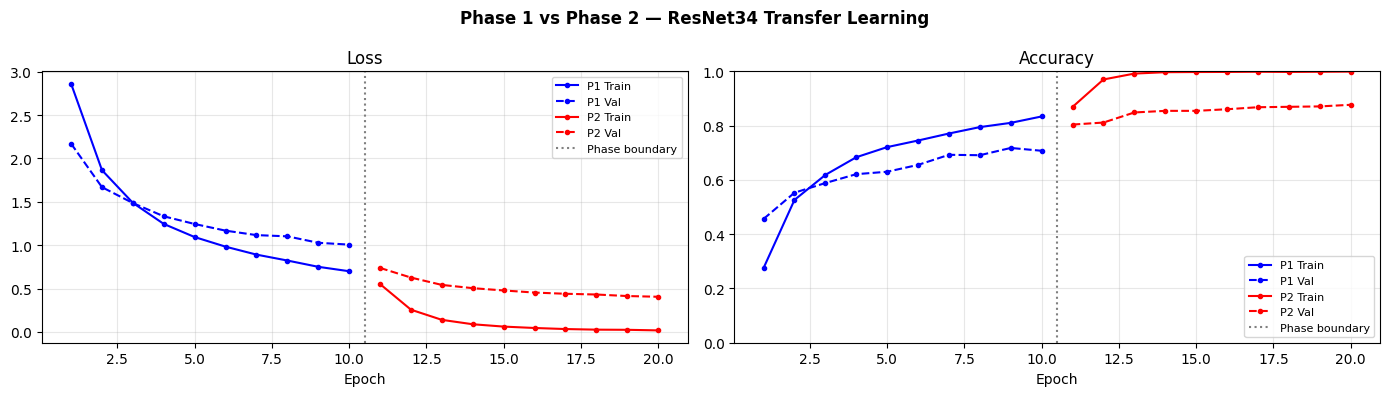

In [32]:
def plot_phase_comparison(hist1, hist2, save_path):
    ep1 = range(1, len(hist1['train_acc']) + 1)
    ep2 = range(len(hist1['train_acc']) + 1,
                len(hist1['train_acc']) + len(hist2['train_acc']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle('Phase 1 vs Phase 2 — ResNet34 Transfer Learning', fontweight='bold')

    for ax, key, label in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
        ax.plot(ep1, hist1[f'train_{key}'], 'b-o', ms=3, label='P1 Train')
        ax.plot(ep1, hist1[f'val_{key}'],   'b--o', ms=3, label='P1 Val')

        ax.plot(ep2, hist2[f'train_{key}'], 'r-o', ms=3, label='P2 Train')
        ax.plot(ep2, hist2[f'val_{key}'],   'r--o', ms=3, label='P2 Val')

        ax.axvline(x=len(hist1['train_acc']) + 0.5,
                    color='gray', linestyle=':', linewidth=1.5,
                    label='Phase boundary')

        ax.set_title(label)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        if key == 'acc':
            ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(block=True)

plot_phase_comparison(hist_p1, hist_p2, OUTPUT_DIR / "resnet34_phase_comparison.png")

### Phase Comparison Table

In [34]:
import json
import pandas as pd
from tabulate import tabulate

rows = [
    {
        'Phase':         'Phase 1 — Feature Extraction',
        'Frozen layers': 'All convolutional blocks',
        'LR':            LR_P1,
        'Epochs':        EPOCHS_P1,
        'Accuracy':      f"{results_p1['acc']:.4f}",
        'Precision':     f"{results_p1['prec']:.4f}",
        'Recall':        f"{results_p1['rec']:.4f}",
        'F1-Score':      f"{results_p1['f1']:.4f}",
    },
    {
        'Phase':         'Phase 2 — Fine-Tuning',
        'Frozen layers': 'Backbone partially unfrozen',
        'LR':            LR_P2,
        'Epochs':        EPOCHS_P2,
        'Accuracy':      f"{results_p2['acc']:.4f}",
        'Precision':     f"{results_p2['prec']:.4f}",
        'Recall':        f"{results_p2['rec']:.4f}",
        'F1-Score':      f"{results_p2['f1']:.4f}",
    },
]

df = pd.DataFrame(rows)
print(tabulate(df, headers='keys', tablefmt='github', showindex=False))

df.to_csv(OUTPUT_DIR / 'resnet34_results.csv', index=False)
print(f"\nSaved results to {OUTPUT_DIR}/resnet34_results.csv")

# Save training histories as JSON
for name, history in [('phase1', hist_p1), ('phase2', hist_p2)]:
    with open(OUTPUT_DIR / f'resnet34_{name}_history.json', 'w') as f:
        json.dump(history, f, indent=2)
    print(f"Saved history: resnet34_{name}_history.json")

| Phase                        | Frozen layers               |    LR |   Epochs |   Accuracy |   Precision |   Recall |   F1-Score |
|------------------------------|-----------------------------|-------|----------|------------|-------------|----------|------------|
| Phase 1 — Feature Extraction | All convolutional blocks    | 0.001 |       10 |     0.612  |      0.7015 |   0.612  |     0.6334 |
| Phase 2 — Fine-Tuning        | Backbone partially unfrozen | 1e-05 |       10 |     0.7958 |      0.8673 |   0.7958 |     0.8126 |

Saved results to C:\Users\kalin\Desktop\outputs_resnet34_tl/resnet34_results.csv
Saved history: resnet34_phase1_history.json
Saved history: resnet34_phase2_history.json
